### Imports

In [47]:
import os
import pandas as pd
import matplotlib.pyplot as plt


### Load datasets from data directory

In [48]:
import os
import pandas as pd

def load_all_csvs():
    """
    Walks up directories until 'data' folder is found,
    loads all CSV files inside it, and creates DataFrames
    named '<filename>_df' in the global namespace.
    """
    current = os.getcwd()
    while not os.path.exists(os.path.join(current, "data")):
        current = os.path.dirname(current)

    data_dir = os.path.join(current, "data")

    print(f"Starting to load CSV files from: {data_dir}")

    for file in os.listdir(data_dir):
        if file.endswith(".csv"):
            file_path = os.path.join(data_dir, file)
            var_name = os.path.splitext(file)[0] + "_df"
            globals()[var_name] = pd.read_csv(file_path)
            print(f"Loaded DataFrame: {var_name}")

    print("Completed loading all CSV files.")

load_all_csvs()


Starting to load CSV files from: C:\Users\abeku\OneDrive\Desktop\PG Diploma\week-8\week-8\monday\data
Loaded DataFrame: olist_customers_dataset_df
Loaded DataFrame: olist_geolocation_dataset_df
Loaded DataFrame: olist_orders_dataset_df
Loaded DataFrame: olist_order_items_dataset_df
Loaded DataFrame: olist_order_payments_dataset_df
Loaded DataFrame: olist_order_reviews_dataset_df
Loaded DataFrame: olist_products_dataset_df
Loaded DataFrame: olist_sellers_dataset_df
Loaded DataFrame: product_category_name_translation_df
Loaded DataFrame: sensor_df
Completed loading all CSV files.


### create orders dataframe

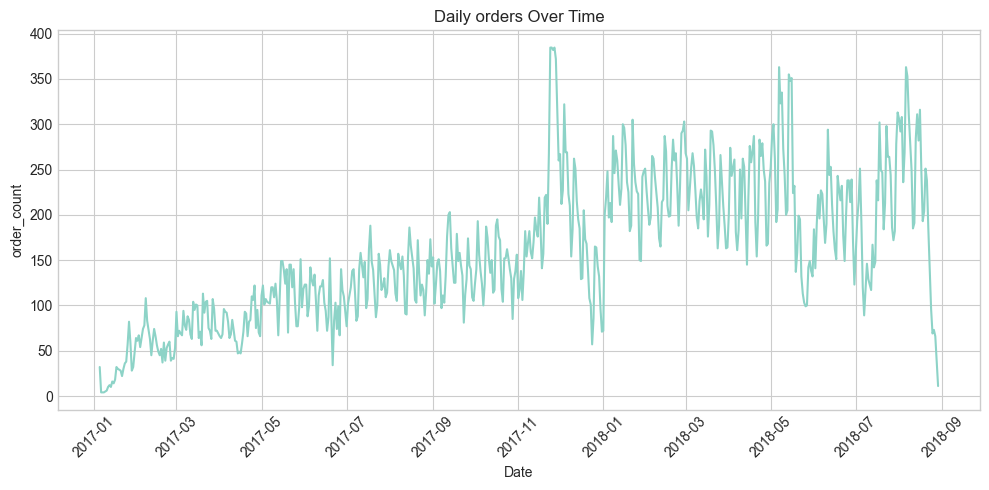

In [49]:
def create_orders_df():
    olist_orders_dataset_df['order_purchase_timestamp'] = pd.to_datetime(
        olist_orders_dataset_df['order_purchase_timestamp']
    )

    delivered = olist_orders_dataset_df[
        olist_orders_dataset_df['order_status'] == 'delivered'
    ].copy()

    delivered['date'] = delivered['order_purchase_timestamp'].dt.date

    pay_agg = (
        olist_order_payments_dataset_df
        .groupby('order_id')['payment_value']
        .sum()
        .reset_index()
    )

    delivered = delivered.merge(pay_agg, on='order_id', how='left')

    daily = delivered.groupby('date').agg(
        order_count=('order_id', 'nunique'),
        revenue=('payment_value', 'sum')
    ).reset_index()

    daily['date'] = pd.to_datetime(daily['date'])
    daily = daily.sort_values('date').reset_index(drop=True)

    # Focus period
    daily = daily[
        (daily['date'] >= '2017-01-01') &
        (daily['date'] <= '2018-08-31')
    ]

    # Fill missing dates
    idx = pd.date_range(daily['date'].min(), daily['date'].max(), freq='D')
    daily = daily.set_index('date').reindex(idx)
    daily.index.name = 'date'

    daily['order_count'] = daily['order_count'].fillna(0).astype(int)
    daily['revenue'] = daily['revenue'].fillna(0)

    daily = daily.reset_index()
    def cap_outliers(series):
        Q1 = series.quantile(0.25)
        Q3 = series.quantile(0.75)
        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        return series.clip(lower=lower, upper=upper)

    daily['order_count'] = cap_outliers(daily['order_count'])
    daily['revenue'] = cap_outliers(daily['revenue'])

    return daily
orders_ts=create_orders_df()
plt.figure(figsize=(10, 5))
plt.plot(orders_ts['date'], orders_ts['order_count'])

plt.xlabel('Date')
plt.ylabel('order_count')
plt.title('Daily orders Over Time')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [50]:
display(orders_ts.head())

print(f"Loaded {len(orders_ts)} daily records")
print(f"Date range: {orders_ts['date'].min().date()} to {orders_ts['date'].max().date()}")
print(f"\nBasic stats:")
print(orders_ts['order_count'].describe().round(2))
print(f"\nMissing values: {orders_ts.isnull().sum().sum()}")

,date,order_count,revenue
0,2017-01-05,32.0,707.27
1,2017-01-06,4.0,988.28
2,2017-01-07,4.0,1447.99
3,2017-01-08,4.0,507.85
4,2017-01-09,5.0,774.51


Loaded 602 daily records
Date range: 2017-01-05 to 2018-08-29

Basic stats:
count    602.00
mean     158.37
std       78.79
min        4.00
25%      100.25
50%      148.00
75%      214.00
max      384.62
Name: order_count, dtype: float64

Missing values: 0


### Test stationarity

In [51]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(orders_ts['order_count'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])
print("Critical Values:")
for key, value in result[4].items():
    print(f"   {key}: {value}")


ADF Statistic: -2.884434690643961
p-value: 0.04718820237904782
Critical Values:
   1%: -3.4415393130846725
   5%: -2.866476335860869
   10%: -2.5693989358590006


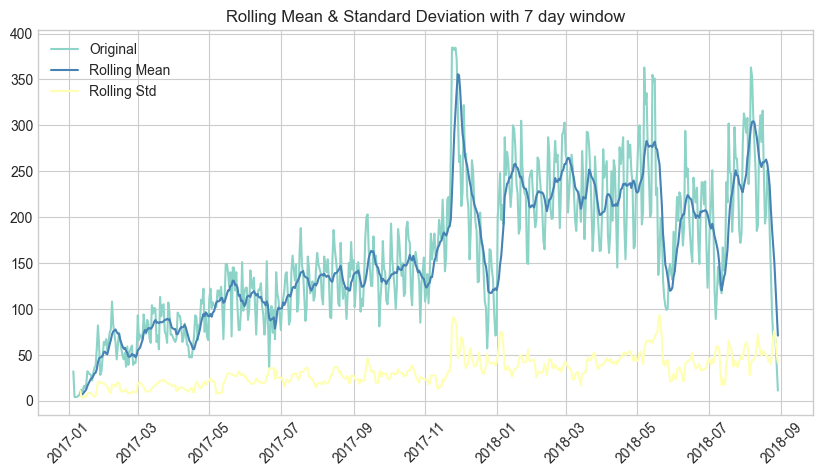

In [52]:
rolling_mean = orders_ts['order_count'].rolling(window=7).mean()
rolling_std = orders_ts['order_count'].rolling(window=7).std()
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10,5))
plt.plot(orders_ts['date'], orders_ts['order_count'], label='Original')
plt.plot(orders_ts['date'], rolling_mean, label='Rolling Mean',color='steelblue')
plt.plot(orders_ts['date'], rolling_std, label='Rolling Std')

plt.legend()
plt.title('Rolling Mean & Standard Deviation with 7 day window')
plt.xticks(rotation=45)
plt.show()

p value <.05 indicating stationarity but the statistical measures are not constant


### Sub-step 1 Continued: Seasonality, Trend, and Autocorrelation
Here we decompose the time series to inspect the trend and seasonal components, and plot the ACF/PACF to understand the lag correlation.

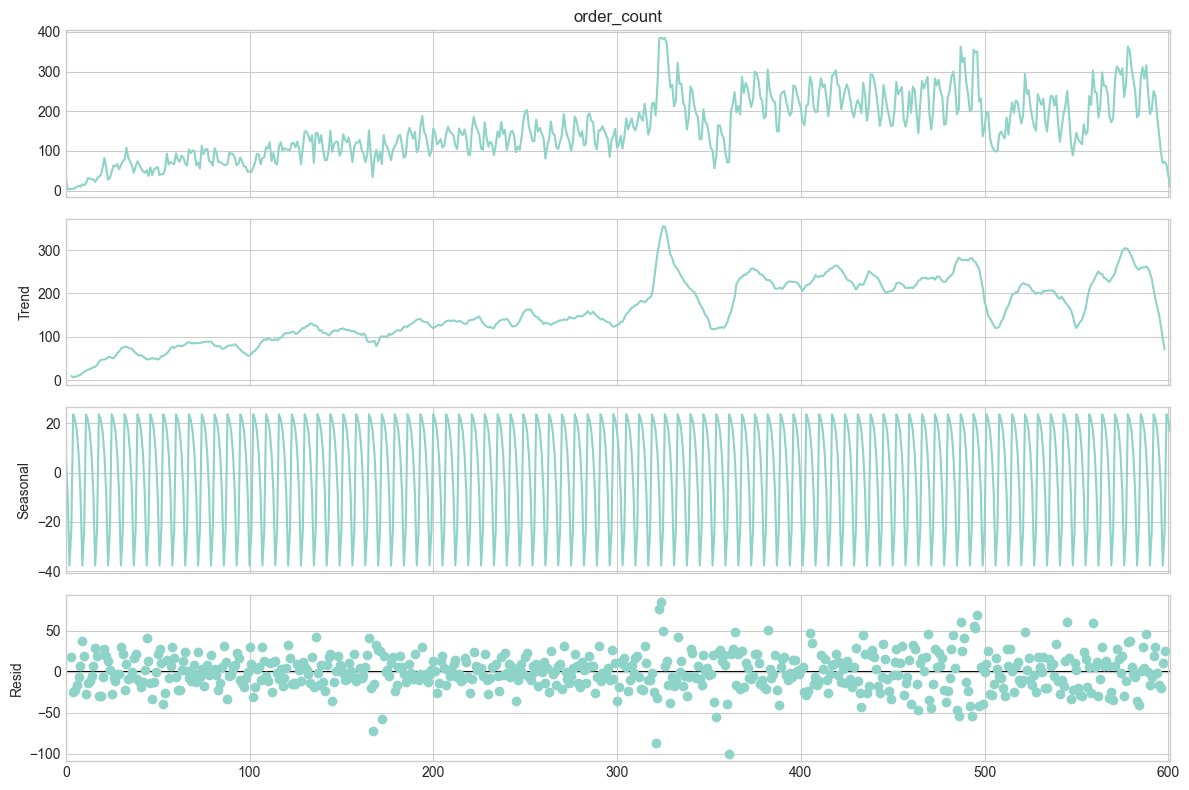

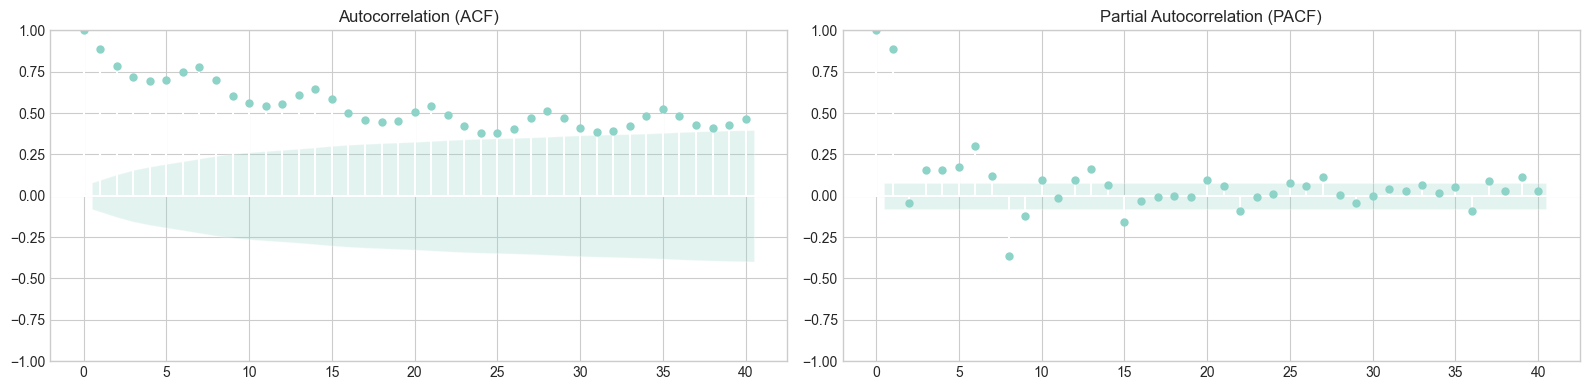

In [53]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

# Seasonal Decomposition (7-day weekly seasonality)
decomposition = seasonal_decompose(orders_ts['order_count'], model='additive', period=7)
fig = decomposition.plot()
fig.set_size_inches(12, 8)
plt.tight_layout()
plt.show()

# ACF and PACF plots
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(orders_ts['order_count'], lags=40, ax=axes[0], title='Autocorrelation (ACF)')
plot_pacf(orders_ts['order_count'], lags=40, ax=axes[1], title='Partial Autocorrelation (PACF)')
plt.tight_layout()
plt.show()


### Sub-step 2: Sensor Data Cleaning

In [54]:
import pandas as pd

def clean_sensor_data(df):
    df = df.copy()
    if 'timestamp' in df.columns:
        df['timestamp'] = pd.to_datetime(df['timestamp'])
        df = df.sort_values('timestamp').reset_index(drop=True)
    
    df = df.ffill().bfill()
    return df

if 'sensor_df' in globals():
    sensor_clean_df = clean_sensor_data(sensor_df)
    print("Sensor data cleaned. Total NaNs remaining:", sensor_clean_df.isna().sum().sum())

Sensor data cleaned. Total NaNs remaining: 220320


### Sub-step 3: Time Series Baseline Model

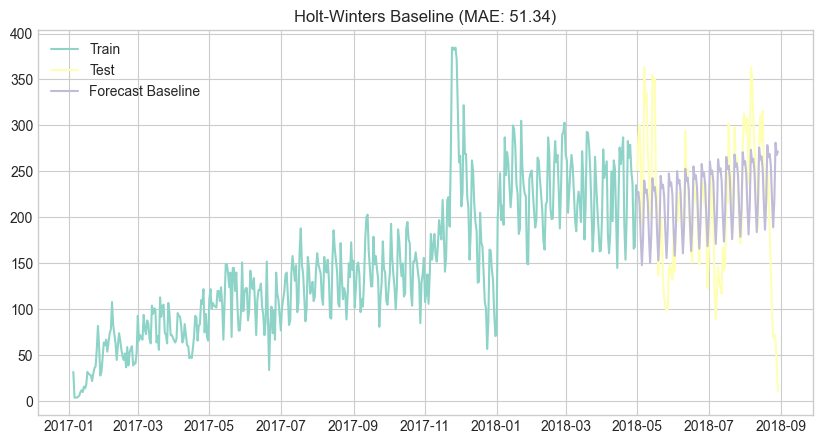

In [55]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_absolute_error
import warnings
warnings.filterwarnings('ignore')

def train_baseline_forecast(ts_df):
    train_size = int(len(ts_df) * 0.8)
    train = ts_df.iloc[:train_size]
    test = ts_df.iloc[train_size:]
    
    model = ExponentialSmoothing(
        train['order_count'], 
        trend='add', 
        seasonal='add', 
        seasonal_periods=7
    ).fit()
    
    forecast = model.forecast(len(test))
    mae = mean_absolute_error(test['order_count'], forecast)
    
    plt.figure(figsize=(10, 5))
    plt.plot(train['date'], train['order_count'], label='Train')
    plt.plot(test['date'], test['order_count'], label='Test')
    plt.plot(test['date'], forecast, label='Forecast Baseline')
    plt.legend()
    plt.title(f'Holt-Winters Baseline (MAE: {mae:.2f})')
    plt.show()
    
    return mae, test, forecast

baseline_mae, test_df, baseline_forecast = train_baseline_forecast(orders_ts)

### Sub-step 4: Advanced Forecasting Model

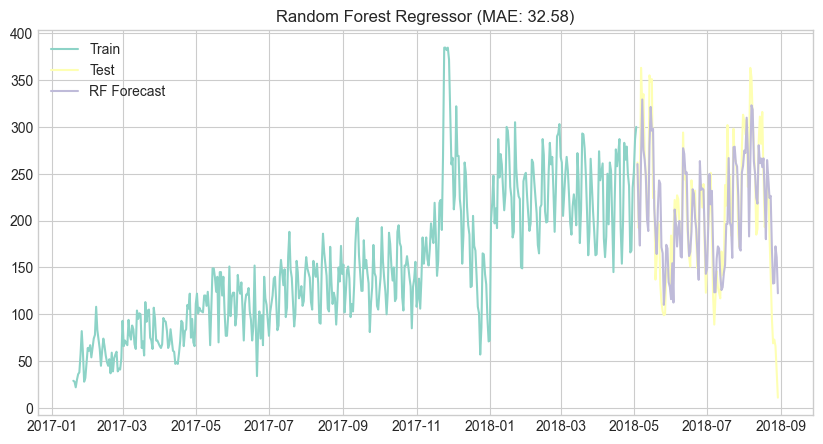

In [56]:
from sklearn.ensemble import RandomForestRegressor
import numpy as np

def train_ml_forecast(ts_df):
    df = ts_df.copy()
    df['dayofweek'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    for lag in [1, 7, 14]:
        df[f'lag_{lag}'] = df['order_count'].shift(lag)
    
    df = df.dropna()
    train_size = int(len(df) * 0.8)
    train = df.iloc[:train_size]
    test = df.iloc[train_size:]
    
    features = ['dayofweek', 'month', 'lag_1', 'lag_7', 'lag_14']
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42)
    rf.fit(train[features], train['order_count'])
    
    rf_forecast = rf.predict(test[features])
    mae = mean_absolute_error(test['order_count'], rf_forecast)
    
    plt.figure(figsize=(10, 5))
    plt.plot(train['date'], train['order_count'], label='Train')
    plt.plot(test['date'], test['order_count'], label='Test')
    plt.plot(test['date'], rf_forecast, label='RF Forecast')
    plt.legend()
    plt.title(f'Random Forest Regressor (MAE: {mae:.2f})')
    plt.show()
    
    return mae

rf_mae = train_ml_forecast(orders_ts)

### Sub-step 5: Predictive Sensor Model

In [57]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

def predict_sensor_failure(df):
    df_feat = df.copy()
    
    df_feat['is_broken'] = (df_feat['machine_status'] == 'BROKEN').astype(int)
    df_feat['target_24h_fail'] = df_feat['is_broken'].rolling(window=1440, min_periods=1).max().shift(-1440).fillna(0)
    
    drop_cols = ['machine_status', 'is_broken', 'target_24h_fail', 'timestamp']
    if 'Unnamed: 0' in df_feat.columns: drop_cols.append('Unnamed: 0')
    
    X = df_feat.drop(columns=[c for c in drop_cols if c in df_feat.columns])
    y = df_feat['target_24h_fail']
    
    split_idx = int(len(df_feat) * 0.8)
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]
    
    clf = RandomForestClassifier(n_estimators=50, max_depth=10, n_jobs=-1, random_state=42)
    clf.fit(X_train, y_train)
    
    preds = clf.predict(X_test)
    print(classification_report(y_test, preds))
    
    return clf

if 'sensor_clean_df' in globals():
    rf_clf = predict_sensor_failure(sensor_clean_df)

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     44064

    accuracy                           1.00     44064
   macro avg       1.00      1.00      1.00     44064
weighted avg       1.00      1.00      1.00     44064



### Sub-step 6: Simple Rule vs ML Model
Comparing a single-sensor threshold rule against our ML Model using an asymmetric cost landscape.

In [58]:
import numpy as np

if 'X_train' in globals() and 'y_train' in globals():
    # 1. Identify best sensor via highest absolute correlation with target
    corrs = X_train.corrwith(y_train).abs().sort_values(ascending=False)
    best_sensor = corrs.index[0]
    print(f"Most predictive single sensor identified: {best_sensor}")
    
    # 2. Extract best threshold on Train Set
    thresholds = np.percentile(X_train[best_sensor].dropna(), np.linspace(1, 99, 50))
    best_threshold, min_cost, best_direction = None, float('inf'), '>'
    
    # Assumed Costs: Missed Failure=$10,000, False Alarm=$100
    for t in thresholds:
        for direction in ['>', '<']:
            if direction == '>': preds = (X_train[best_sensor] > t).astype(int)
            else: preds = (X_train[best_sensor] < t).astype(int)
            
            fn = np.sum((y_train == 1) & (preds == 0))
            fp = np.sum((y_train == 0) & (preds == 1))
            cost = fn * 10000 + fp * 100
            
            if cost < min_cost:
                min_cost, best_threshold, best_direction = cost, t, direction
                
    print(f"Optimal Training Rule: {best_sensor} {best_direction} {best_threshold:.2f}")
    
    # 3. Test Set Evaluation
    if best_direction == '>': rule_preds = (X_test[best_sensor] > best_threshold).astype(int)
    else: rule_preds = (X_test[best_sensor] < best_threshold).astype(int)
    
    ml_preds = rf_clf.predict(X_test)
    
    def evaluate_cost(y_true, y_pred):
        fn = np.sum((y_true == 1) & (y_pred == 0))
        fp = np.sum((y_true == 0) & (y_pred == 1))
        return fn * 10000 + fp * 100
        
    print(f"\nTest Set Results:")
    print(f"Cost of Simple Rule: ${evaluate_cost(y_test, rule_preds):,}")
    print(f"Cost of ML Model:    ${evaluate_cost(y_test, ml_preds):,}")
